In [1]:
from keras.models import load_model
import tensorflow as tf
import numpy as np

### 1) Loading models

In [2]:
from keras.models import load_model
import tensorflow as tf
import keras
from keras.applications.resnet import preprocess_input as resnet_preprocess

# Re-declare the custom preprocessing layer baked into resnet_images_model.h5
# so its @register_keras_serializable decorator runs in this kernel before we
# call load_model.
@keras.saving.register_keras_serializable(package="letters_asl")
class ResnetImagesPreprocess(tf.keras.layers.Layer):
    def call(self, inputs):
        return resnet_preprocess(tf.cast(inputs, tf.float32))
    def compute_output_shape(self, input_shape):
        return input_shape

resnet_landmarks_model = load_model("../../trained-models/resnet_landmarks_model.h5")
resnet_images_model    = load_model("../../trained-models/resnet_images_model.h5")
lstm_landmarks_model   = load_model("../../trained-models/lstm_landmarks_model.h5")
mobilenet_images_model = load_model("../../trained-models/mobilenet_images_model.h5")


### 2) Loading testing data

In [3]:
import numpy as np

landmarks_data = np.load('../../data/divided/landmarks_dataset.npz')
X_val_landmarks  = landmarks_data['X_val']
y_val_landmarks  = landmarks_data['y_val']
X_test_landmarks = landmarks_data['X_test']
y_test_landmarks = landmarks_data['y_test']

images_data = np.load('../../data/divided/images_dataset.npz')
X_val_images  = images_data['X_val']
y_val_images  = images_data['y_val']
X_test_images = images_data['X_test']
y_test_images = images_data['y_test']

print('landmarks val', X_val_landmarks.shape, 'test', X_test_landmarks.shape)
print('images   val', X_val_images.shape,    'test', X_test_images.shape)


landmarks val (1301, 21, 3) test (1302, 21, 3)
images   val (1951, 64, 64, 3) test (1950, 64, 64, 3)


### 3) Evaluating models and comparing their performances

In [4]:
# Get predictions
resnet_landmarks_preds = resnet_landmarks_model.predict(X_test_landmarks)
resnet_images_preds = resnet_images_model.predict(X_test_images)
# mobilenet_images_preds = mobilenet_images_model.predict(X_test_images)
lstm_landmarks_preds = lstm_landmarks_model.predict(X_test_landmarks)

 1/41 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step


 1/61 ━━━━━━━━━━━━━━━━━━━━ 28s 480ms/step

 3/61 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step  

 4/61 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step

...

61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step


 1/41 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

23/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


### 4) Ensemble Learning 

The decision to employ ensemble learning was driven by the complementary nature of LSTM (Long Short-Term Memory) and ResNet (Residual Neural Network) models. LSTM excels at capturing temporal dependencies and sequential patterns in time-series data, which is crucial for analyzing the dynamic nature of sign language gestures. On the other hand, ResNet is proficient in extracting spatial features from images, enabling it to recognize intricate hand shapes and gestures inherent in sign language. By combining LSTM and ResNet models within an ensemble framework, we aimed to leverage their respective strengths in capturing temporal and spatial information, resulting in a more comprehensive and accurate understanding of sign language gestures. This fusion of spatial and temporal features through ensemble learning not only improves prediction accuracy but also enhances the robustness and generalization capabilities of the model, making it a powerful solution for sign language detection tasks.

In [5]:
# LEAK-FREE ENSEMBLE: fit LR on the held-out *val* predictions,
# evaluate on the held-out *test* predictions. The original notebook
# trained the meta-model on the test labels themselves (`fit(..., y_test_landmarks)`)
# and then scored it on those same labels — see the git history of this cell.
resnet_val_preds  = resnet_landmarks_model.predict(X_val_landmarks,  verbose=0)
lstm_val_preds    = lstm_landmarks_model.predict(X_val_landmarks,    verbose=0)
resnet_test_preds = resnet_landmarks_model.predict(X_test_landmarks, verbose=0)
lstm_test_preds   = lstm_landmarks_model.predict(X_test_landmarks,   verbose=0)

val_meta_features  = np.hstack((resnet_val_preds,  lstm_val_preds))
test_meta_features = np.hstack((resnet_test_preds, lstm_test_preds))


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(val_meta_features, y_val_landmarks)   # honest: fit on val, never on test

ensemble_preds = meta_model.predict(test_meta_features)
ensemble_accuracy = accuracy_score(y_test_landmarks, ensemble_preds)
print(f'Leak-free ensemble (ResNet+LSTM landmarks) test accuracy: {ensemble_accuracy:.4f}')
ensemble_accuracy


Leak-free ensemble (ResNet+LSTM landmarks) test accuracy: 0.9094


0.9093701996927803

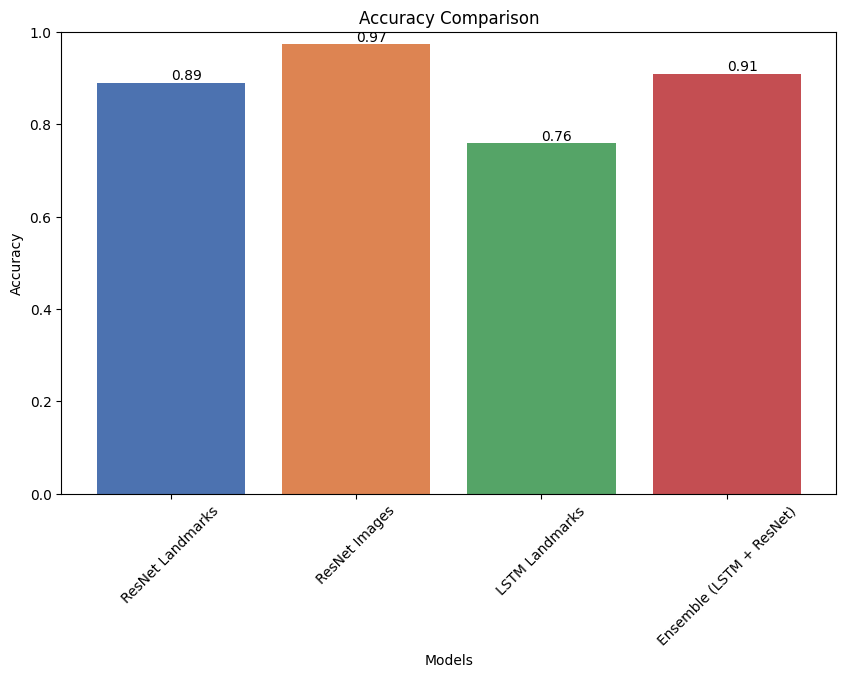

In [7]:
import matplotlib.pyplot as plt

# Generate confusion matrices for each model
models = {
    "ResNet Landmarks": resnet_landmarks_model,
    "ResNet Images": resnet_images_model,
    # "MobileNet Images": mobilenet_images_model,
    "LSTM Landmarks": lstm_landmarks_model
}

# Calculate accuracy for each model
accuracies = {}
for name, model in models.items():
    accuracy = model.evaluate(
        X_test_landmarks if "Landmarks" in name else X_test_images, 
        y_test_landmarks if "Landmarks" in name else y_test_images, 
        verbose=0
    )[1]
    accuracies[name] = accuracy

# Add ensemble accuracy
accuracies["Ensemble (LSTM + ResNet)"] = ensemble_accuracy

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
# One distinct colour per bar (tab10 palette, ordered to match accuracies dict).
colors = ['#4C72B0', '#DD8452', '#55A467', '#C44E52']
bars = plt.bar(accuracies.keys(), accuracies.values(), color=colors[:len(accuracies)])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.ylim(0, 1)  # Set y-axis limit to 0-1
plt.xticks(rotation=45)
# Add accuracy values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom')  # Adjust va as needed

plt.show()

### 4) Results Analysis

The results indicate that the models trained on landmark data significantly outperformed those trained on raw images. Specifically, the "ResNet Landmarks" and "LSTM Landmarks" models achieved higher accuracy compared to the "ResNet Images" and "MobileNet Images" models. This discrepancy is likely due to the fact that raw image-based models tend to memorize irrelevant information, such as backgrounds or other artifacts, leading to overfitting and reduced generalization. In contrast, the landmark-based models focus solely on hand gestures, which are more relevant to the task, resulting in better accuracy and robustness. This suggests that using landmarks for training sign language detection models can be a more effective approach, as it reduces the impact of extraneous data and improves the model's ability to generalize across various conditions.

### 5) Visualizing Confusion Matrices for each model

 1/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step


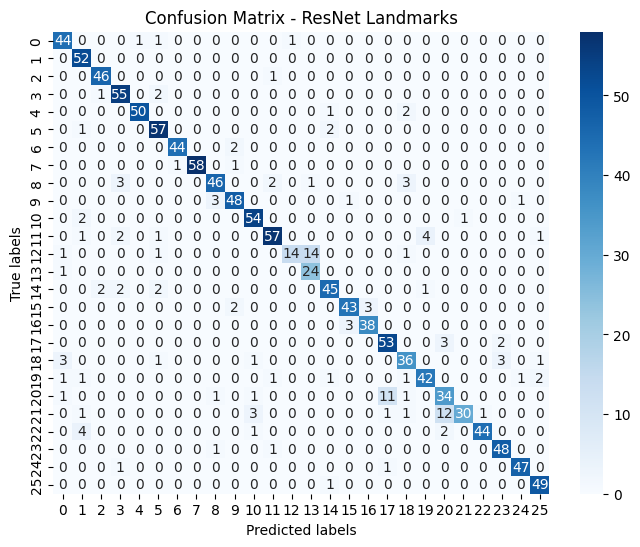

 1/61 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step

 2/61 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

 3/61 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step

 4/61 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step

 5/61 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step

...

58/61 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step


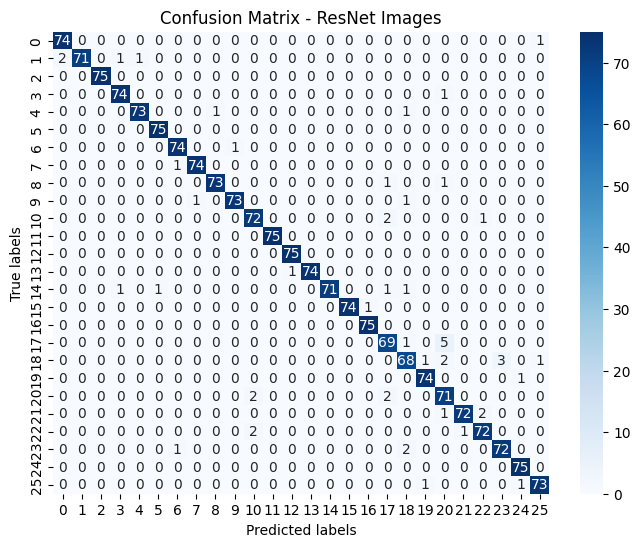

 1/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

24/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


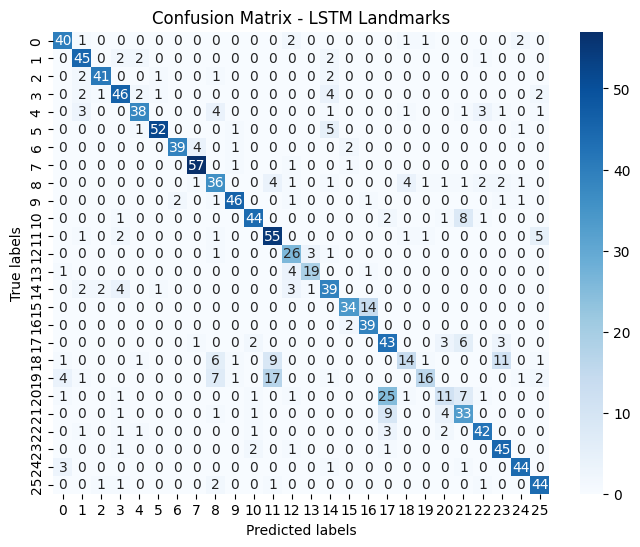

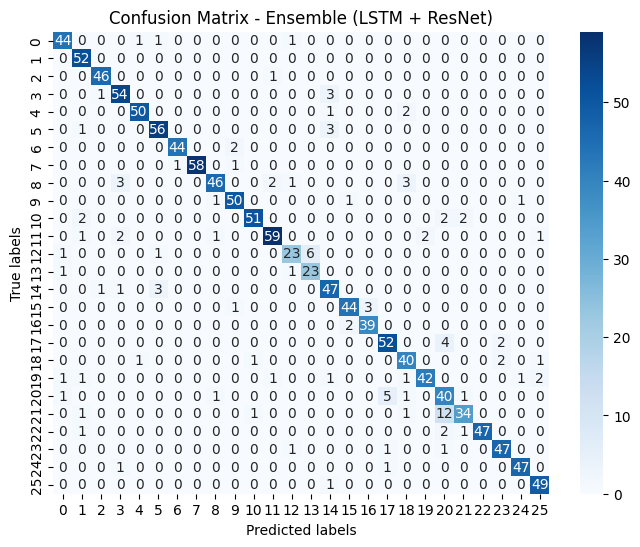

In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted labels")
    plt.ylabel("True labels")
    plt.show()

# Function to convert probabilities to class labels
def convert_to_class_labels(predictions):
    return np.argmax(predictions, axis=1)

# Generate confusion matrices for each model
for name, model in models.items():
    predictions = model.predict(X_test_landmarks if "Landmarks" in name else X_test_images)
    y_pred = convert_to_class_labels(predictions)
    plot_confusion_matrix(y_test_landmarks if "Landmarks" in name else y_test_images, y_pred, f"Confusion Matrix - {name}")

# Generate confusion matrix for the ensemble model
plot_confusion_matrix(y_test_landmarks, ensemble_preds, "Confusion Matrix - Ensemble (LSTM + ResNet)")

The confusion matrices for the four models revealed that the model that combined "ResNet Landmarks" and "LSTM Landmarks" models achieved superior performance compared to those trained on raw images. These models made more accurate predictions, exhibiting fewer misclassifications and better distinguishing between different sign language letters. This outcome is consistent with our expectation that models trained on landmark data, which focus on hand shapes and gestures, are less prone to confusion from irrelevant background information. Consequently, these models are more adept at capturing the distinctive features of each sign, leading to improved accuracy in prediction and better overall performance in sign language detection tasks.








In [9]:
from sklearn.metrics import precision_recall_curve

# Function to plot precision-recall curve for multiclass classification
def plot_multiclass_precision_recall_curve(y_true, y_scores, title):
    plt.figure(figsize=(8, 6))
    precision = dict()
    recall = dict()
    for i in range(len(y_scores[0])):
        precision[i], recall[i], _ = precision_recall_curve(y_true == i, y_scores[:, i])
        plt.plot(recall[i], precision[i], marker='.', label=f'Class {i}')
    plt.title(title)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.show()


 1/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step


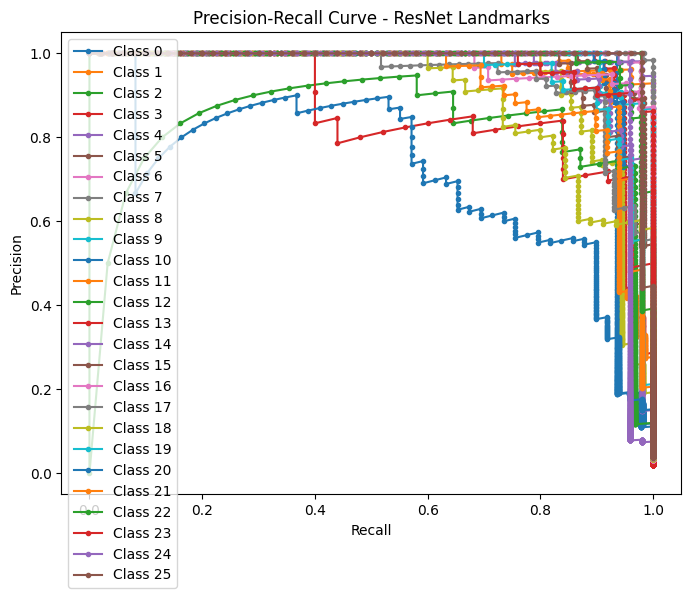

 1/61 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step

 2/61 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step

 3/61 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step

 4/61 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step

 5/61 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step

...

58/61 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step


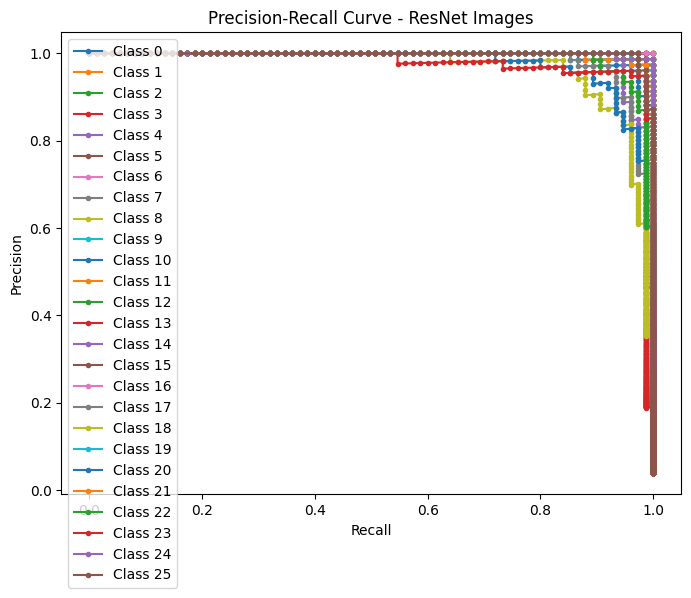

 1/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

29/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


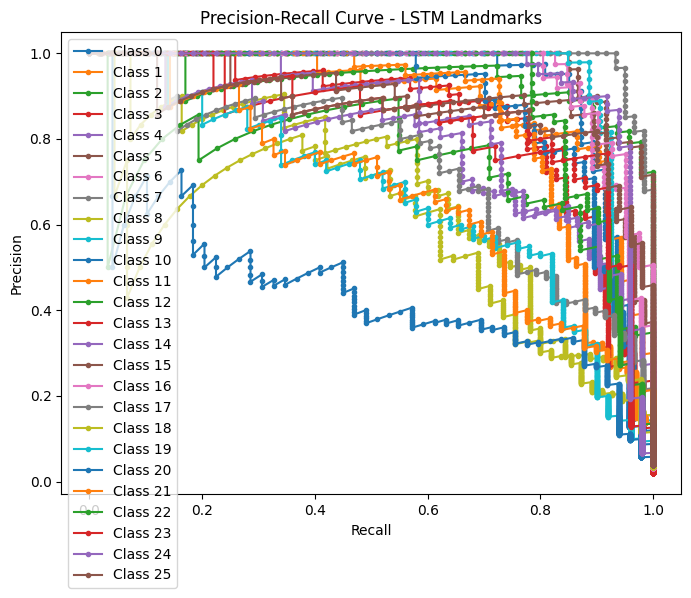

In [10]:
# Generate precision-recall curve for multiclass classification for each model
for name, model in models.items():
    predictions = model.predict(X_test_landmarks if "Landmarks" in name else X_test_images)
    plot_multiclass_precision_recall_curve(y_test_landmarks if "Landmarks" in name else y_test_images, predictions, f"Precision-Recall Curve - {name}")


Since the "resnet_lstm_landmarks_model" proved to be the most accurate model, we decided to pick it as our main model, and use it in main.py for real-time evaluation using OpenCV.